In [2]:
# Importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Importing modules from sklearn library
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve, accuracy_score

# Importing harmless warnings
import warnings
warnings.filterwarnings('ignore')

# Notebook formatting
pd.set_option('display.max_columns', None)

In [3]:
# Import data
data = pd.read_csv('Breast_cancer_dataset.csv')

In [4]:
# Sample
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
# Data shape
data.shape

(569, 33)

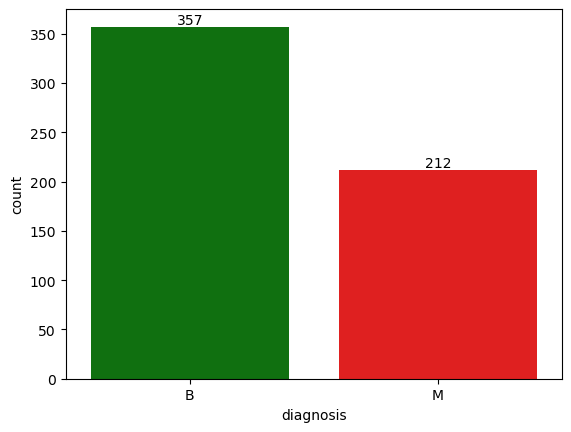

In [6]:
# Analysing target column as countplot
ax = sns.countplot(data = data, x = data['diagnosis'], order = data['diagnosis'].value_counts().index, palette = {'green', 'red'})
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.show()

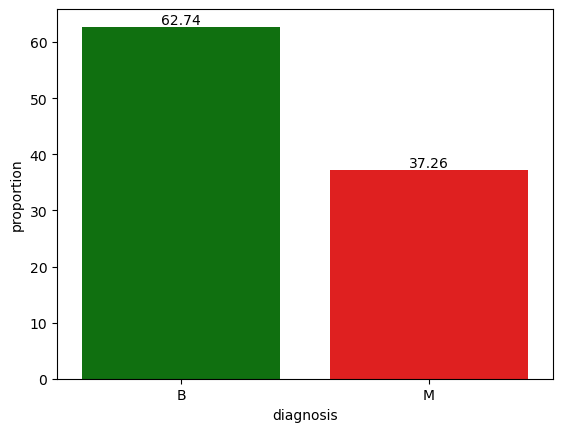

In [7]:
# Percentage plot
ax = sns.barplot(round(data['diagnosis'].value_counts(normalize=True)*100, 2), palette = {'green', 'red'})
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.show()

In [8]:
# Removing unnecessary columns
data.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)

In [9]:
#Data Shape after dropping unnecessary columns
data.shape

(569, 31)

In [10]:
# Convert the target to binary
data['diagnosis'] = data['diagnosis'].map({'B' : 0, 'M' : 1})

# Data variable split
x = data.iloc[:, 1:]
y = data[['diagnosis']]

# Train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

# Dimension of the split
print('Dimension after splitting')

print('\nDimensions of Training Columns:')
print(x_train.shape, y_train.shape)

print('\nDimensions of Testing Columns:')
print(x_test.shape, y_test.shape)

Dimension after splitting

Dimensions of Training Columns:
(398, 30) (398, 1)

Dimensions of Testing Columns:
(171, 30) (171, 1)


In [11]:
# Hyper parameter tuning for random forest

# Start Timer
start_time = time.time()

# Initialize Random Forest Classifier
rf_cv = RandomForestClassifier(random_state=42)  # random_state ensures reproducibility

# Set Up GridSearchCV for Hyperparameter Tuning
hyper_fit = GridSearchCV(
    estimator=rf_cv,       # the model to tune
    param_grid={           # dictionary of hyperparameters to try
        'criterion': ['gini', 'entropy'],       # split quality metrics
        'bootstrap': [True, False],            # use bootstrap samples or not
        'max_features': ['sqrt', 'log2', None, 'auto']  # number of features considered at each split
    },
    cv=5,                  # 5-fold cross-validation
    n_jobs=-1              # use all CPU cores for parallel processing
)

# Fit GridSearchCV to the Training Data
hyper_fit.fit(x_train, y_train)  # trains and evaluates all combinations using CV

# Display the Best Hyperparameters Found
print('Best Parameters from the grid search:', hyper_fit.best_params_)

# End Timer and Show Time Taken
end_time = time.time()
print('Time taken for grid search:', round(end_time - start_time, 2), 's')

Best Parameters form the grid search: {'bootstrap': True, 'criterion': 'entropy', 'max_features': 'sqrt'}
Time taken for grid search: 12.65 s


In [12]:
# Setting the best parameter to the model
best_params = hyper_fit.best_params_
final_model = RandomForestClassifier(**best_params, random_state = 42)

In [14]:
# OOB - Out of bag
final_model.set_params(oob_score = True, warm_start = True, n_jobs = -1)

# Number of trees
min_trees, max_trees = 15, 700

# Error rate
error_rate = {}   # tree_no : error_rate

# Iteration to find the error rate of the trees
for tree in range(min_trees, max_trees):
    final_model.set_params(n_estimators = tree)
    final_model.fit(x_train, y_train)
    oob_error = 1 - final_model.oob_score_
    error_rate[tree] = oob_error

In [17]:
# Convert the dictionary to pandas series
oob_data = pd.Series(error_rate)
oob_data

15     0.052764
16     0.047739
17     0.045226
18     0.050251
19     0.052764
         ...   
695    0.042714
696    0.042714
697    0.042714
698    0.042714
699    0.042714
Length: 685, dtype: float64

In [30]:
# To get values between index 2 and 4 (inclusive)
subset = oob_data.loc[290:310]  # Indexes are inclusive of the start, exclusive of the end
print(subset)

290    0.047739
291    0.047739
292    0.047739
293    0.047739
294    0.047739
295    0.047739
296    0.047739
297    0.047739
298    0.047739
299    0.047739
300    0.047739
301    0.047739
302    0.047739
303    0.047739
304    0.047739
305    0.047739
306    0.050251
307    0.050251
308    0.050251
309    0.050251
310    0.050251
dtype: float64


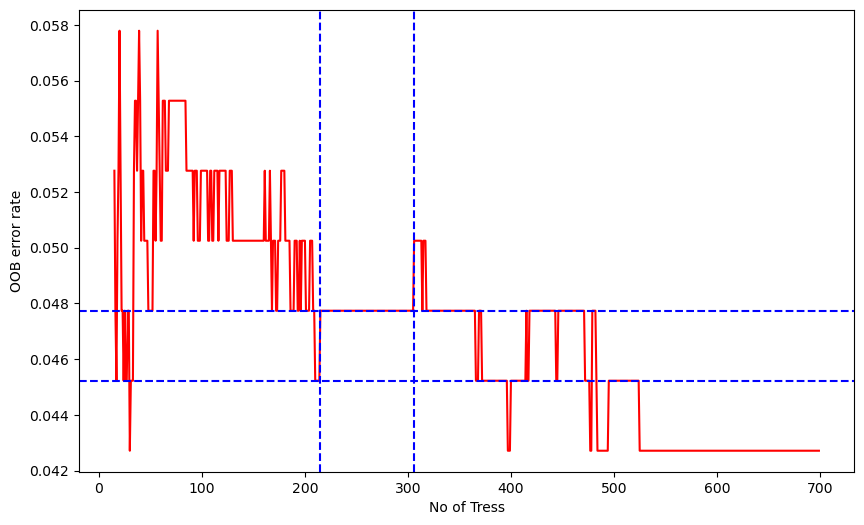

In [29]:
# plot the oob against the number of trees
plt.figure(figsize=(10,6))
oob_data.plot(kind = 'line', color = 'r')
plt.xlabel('No of Tress')
plt.ylabel('OOB error rate')
plt.axhline(0.045226, color = 'b', ls = '--')
plt.axhline(0.047739, color = 'b', ls = '--')
plt.axvline(215, color = 'b', ls = '--')
plt.axvline(306, color = 'b', ls = '--')
plt.show()

In [31]:
# Check the final model params before fitting the estimators
print(final_model.get_params)

<bound method BaseEstimator.get_params of RandomForestClassifier(criterion='entropy', n_estimators=699, n_jobs=-1,
                       oob_score=True, random_state=42, warm_start=True)>


<bound method BaseEstimator.get_params of RandomForestClassifier(criterion='entropy', n_estimators=261, n_jobs=-1,
                       random_state=42)>

Training Score: 100.0 %
Testing Score: 97.08 %
Classification Report:

               precision    recall  f1-score   support

           0       0.96      0.99      0.98       108
           1       0.98      0.94      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



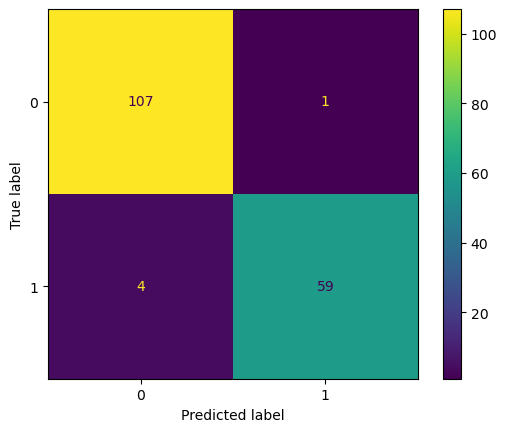

In [32]:
# Refining the trees via OOB
final_model.set_params(n_estimators=261, warm_start=False, oob_score=False, random_state=42)

# Final model parameters
print(final_model.get_params)

# Model training
final_model.fit(x_train, y_train)

# Training score
print('\nTraining Score:', round(final_model.score(x_train, y_train)*100, 2), '%')

# Predictions
y_pred = final_model.predict(x_test)

# Metrics
print('Testing Score:', round(accuracy_score(y_test, y_pred)*100, 2), '%')
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print('Classification Report:\n\n', classification_report(y_test, y_pred))

In [77]:
# Finding feature importances from the final model
importances = final_model.feature_importances_
importances

array([0.03548984, 0.01987122, 0.04057869, 0.03868013, 0.00685867,
       0.01397808, 0.06011028, 0.12218307, 0.00546386, 0.00601131,
       0.01607256, 0.00473847, 0.00975853, 0.02505396, 0.00551141,
       0.00765255, 0.00666392, 0.00670104, 0.00737566, 0.0077204 ,
       0.06855374, 0.02961475, 0.12227814, 0.11050976, 0.01343152,
       0.01746074, 0.0409879 , 0.12621271, 0.01757219, 0.00690488])

In [78]:
# Index of the above array
indx = np.argsort(importances)
indx

array([11,  8, 14,  9, 16, 17,  4, 29, 18, 15, 19, 12, 24,  5, 10, 25, 28,
        1, 13, 21,  0,  3,  2, 26,  6, 20, 23,  7, 22, 27], dtype=int64)

In [79]:
# Finding feature names
name_indx = list(x.columns)
name_indx

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

In [125]:
# Create DataFrame with Importances and Column Index
impurity_df = pd.DataFrame({
    'mean_impurity': importances,   # importance values from the model
    'column_index': indx            # indices of features sorted
})

# Map Column Index to Column Names
impurity_df['column_name'] = impurity_df['column_index'].apply(lambda x: name_indx[x])  # lambda function is used to map each index to its corresponding feature name    

# Select Only Relevant Columns
impurity_df = impurity_df[['column_name', 'mean_impurity']]  # keep only feature names and importance

# Sort Features by Importance (Descending)
impurity_df = impurity_df.sort_values(by='mean_impurity', ascending=False)  
# most important features appear at the top

# Reset Index
impurity_df = impurity_df.reset_index(drop=True)  # reset index after sorting to have sequential indices

# Calculate Percentage Importance
impurity_df['percentage_impurity'] = round(impurity_df['mean_impurity'] * 100, 3)  # convert importance to percentage and round to 3 decimals

# Calculate Cumulative Importance
impurity_df['cum_impurity'] = impurity_df['percentage_impurity'].cumsum()  # cumulative sum to see total contribution of top features

# Display the DataFrame
impurity_df

,column_name,mean_impurity,percentage_impurity,cum_impurity
0,concave points_mean,0.126213,12.621,12.621
1,perimeter_mean,0.122278,12.228,24.849
2,fractal_dimension_worst,0.122183,12.218,37.067
3,concavity_worst,0.110510,11.051,48.118
4,radius_mean,0.068554,6.855,54.973
5,smoothness_mean,0.060110,6.011,60.984
6,area_worst,0.040988,4.099,65.083
7,smoothness_se,0.040579,4.058,69.141
8,fractal_dimension_mean,0.038680,3.868,73.009
9,texture_se,0.035490,3.549,76.558


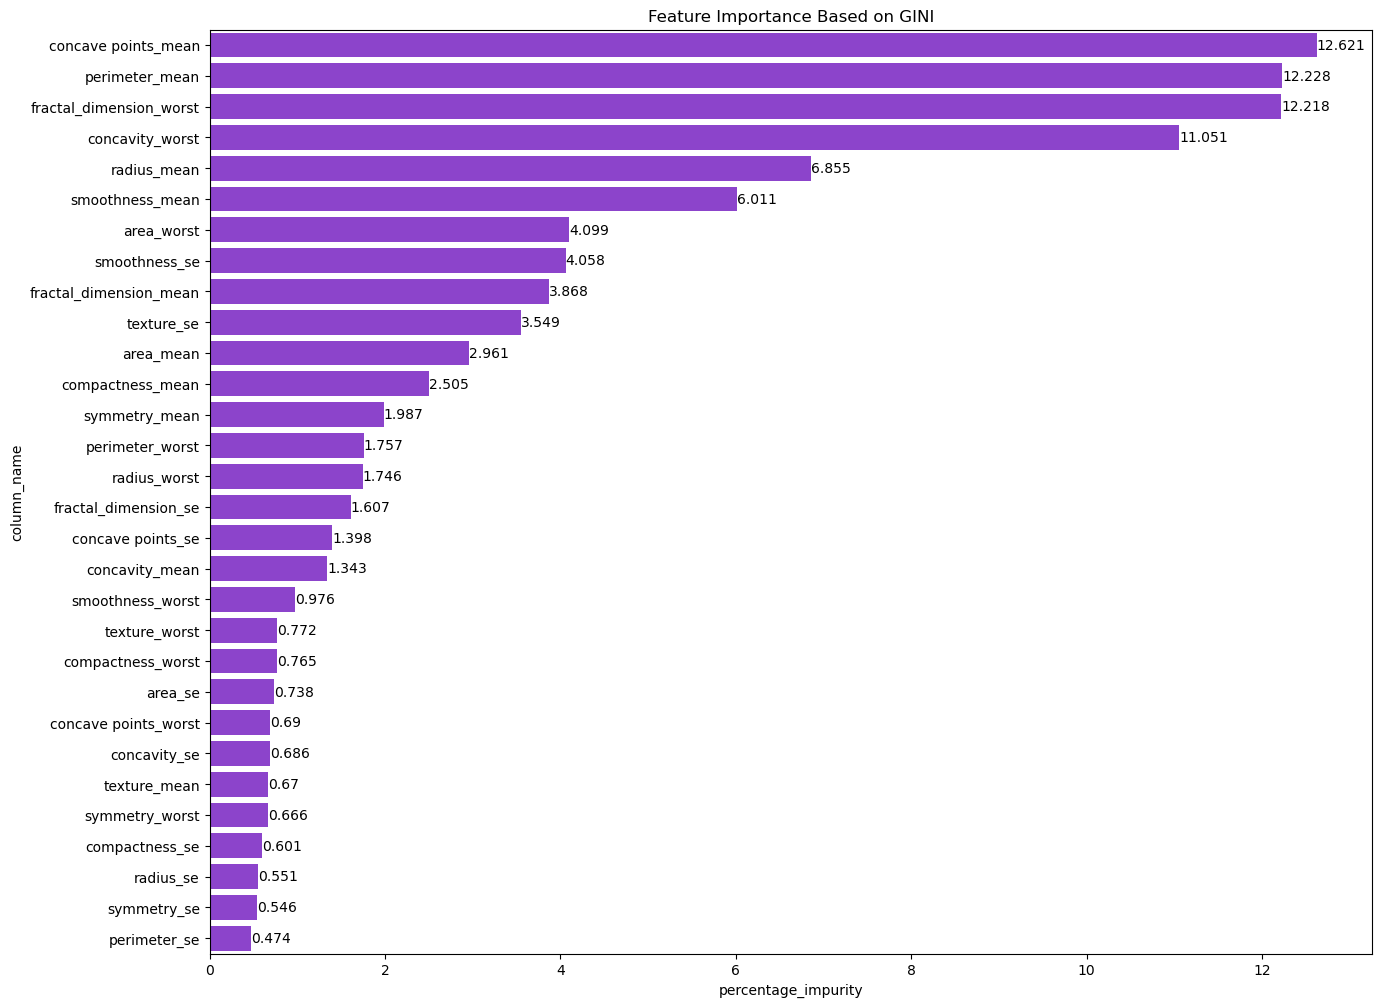

In [121]:
# Feature importance graph with horizontal bars
plt.figure(figsize=(15,12))
ax = sns.barplot(data = impurity_df, y = 'column_name', x = 'percentage_impurity', color='#8e2de2')
ax.bar_label(ax.containers[0])
plt.title('Feature Importance Based on GINI')
plt.show()

In [122]:
# Filtering the columns with 90% mean impurity
final_columns = list(impurity_df[impurity_df['cum_impurity'] <= 90].column_name)

# Filtering the x_train and x_test data for above columns
x_train_filtered = x_train[final_columns]
x_test_filtered = x_test[final_columns]


Training Score: 100.0 %
Testing Score: 97.66 %
Classification Report:

               precision    recall  f1-score   support

           0       0.97      0.99      0.98       108
           1       0.98      0.95      0.97        63

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



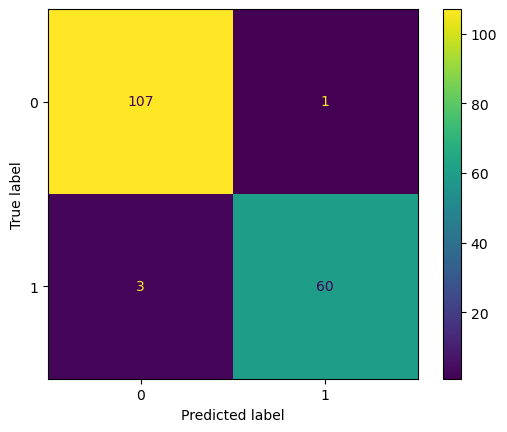

In [123]:
# Optimized model
final_params = final_model.get_params()
opt_model = RandomForestClassifier(**final_params)

# Training the data
opt_model.fit(x_train_filtered, y_train)

# Training score
print('\nTraining Score:', round(opt_model.score(x_train_filtered, y_train)*100, 2), '%')

# Predictions
opt_y_pred = opt_model.predict(x_test_filtered)

# Metrics
print('Testing Score:', round(accuracy_score(y_test, opt_y_pred)*100, 2), '%')
cm = ConfusionMatrixDisplay.from_predictions(y_test, opt_y_pred)
print('Classification Report:\n\n', classification_report(y_test, opt_y_pred))